### 구글 드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 라이브러리 설치 및 import

In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 89.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

### USGS 기준 PGV 범례
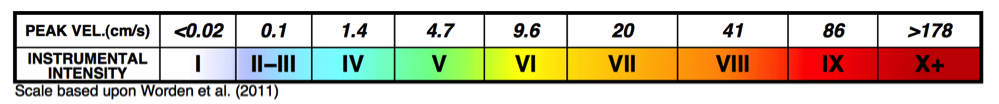

### 위험지도 생성

  유효 격자점 수: 46,032
  지도 범위: 위도 36.35°~41.81°, 경도 138.65°~141.99°


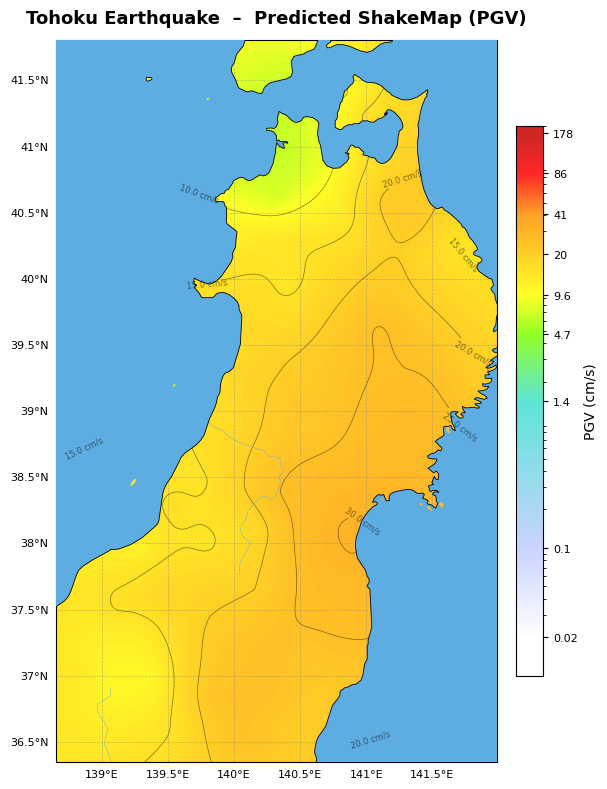

ShakeMap 저장 완료: /content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/0508 논문 데이터/tohoku_pred_25km_360_180_shakemap.png


In [ ]:
INPUT_GRID_CSV  = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/0508 논문 데이터/tohoku_kriging_pred_25km_360_180.csv"
#INPUT_GRID_CSV  = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/0508 논문 데이터/noto_kriging_pred_25km_360_180.csv"
OUTPUT_FIG_PATH = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/0508 논문 데이터/tohoku_pred_25km_360_180_shakemap.png"
#OUTPUT_FIG_PATH = "/content/drive/MyDrive/TriAI/그로쓰/Data/postprocessing/0508 논문 데이터/noto_pred_25km_360_180_shakemap.png"

PGV_MIN = 0.01
PGV_MAX = 200.0

DPI = 200

# USGS 기준 PGV 경계값 리스트
pgv_bounds = [0.0, 0.02, 0.1, 1.4, 4.7, 9.6, 20.0, 41.0, 86.0, 178.0, 300.0]

# 각 구간에 들어갈 색상
pgv_colors_list = [
    (0.01,  "#FFFFFF"),
    (0.02,  "#FFFFFF"),
    (0.10,  "#BFCCFF"),
    (1.40,  "#40E0D0"),
    (4.70,  "#7FFF00"),
    (9.60,  "#FFFF00"),
    (20.0,  "#FFC800"),
    (41.0,  "#FF9100"),
    (86.0,  "#FF0000"),
    (178.0, "#C80000"),
    (200.0, "#C80000")
]

# 로그 스케일 환경에서 각 값이 위치할 0.0 ~ 1.0 사이의 비율 계산
log_min = np.log10(PGV_MIN)
log_max = np.log10(PGV_MAX)

color_list = []
for val, color in pgv_colors_list:
    pos = (np.log10(val) - log_min) / (log_max - log_min)
    pos = max(0.0, min(1.0, pos))
    color_list.append((pos, color))

# 최종 컬러맵 및 로그 스케일 규격 생성
pgv_cmap = mcolors.LinearSegmentedColormap.from_list("usgs_shakemap_gradient", color_list)
log_norm = mcolors.LogNorm(vmin=PGV_MIN, vmax=PGV_MAX)

def load_grid(csv_path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["lat", "lon", "pgv_kriged_pred"])
    df = df[df["pgv_kriged_pred"] > 0].copy()
    return df

def pivot_grid(df: pd.DataFrame):
    grid_lats = np.sort(df["lat"].unique())
    grid_lons = np.sort(df["lon"].unique())

    lon_2d, lat_2d = np.meshgrid(grid_lons, grid_lats)

    pgv_2d = (
        df.pivot_table(index="lat", columns="lon", values="pgv_kriged_pred")
        .reindex(index=grid_lats, columns=grid_lons)
        .values
    )
    var_2d = (
        df.pivot_table(index="lat", columns="lon", values="kriging_var")
        .reindex(index=grid_lats, columns=grid_lons)
        .values
    )

    return lon_2d, lat_2d, pgv_2d, var_2d

def add_map_features(ax):
    ax.add_feature(cfeature.LAND,      facecolor="white", zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor="#5DADE2", zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, edgecolor="black", zorder=4)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="gray", zorder=4, linestyle="--")
    ax.add_feature(cfeature.RIVERS,    linewidth=0.3, edgecolor="#5DADE2", zorder=4)

def add_gridlines(ax):
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xformatter   = LONGITUDE_FORMATTER
    gl.yformatter   = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}
    gl.xlocator = mticker.MultipleLocator(0.5)
    gl.ylocator = mticker.MultipleLocator(0.5)

def add_pgv_colorbar(fig, mesh, ax):
    cbar = fig.colorbar(
        mesh,
        ax=ax,
        orientation="vertical",
        fraction=0.03,
        pad=0.02,
        shrink=0.85,
    )
    cbar.set_label("PGV (cm/s)", fontsize=10)

    # 눈금 위치 지정
    pgv_ticks = [0.02, 0.1, 1.4, 4.7, 9.6, 20.0, 41.0, 86.0, 178.0]
    cbar.set_ticks(pgv_ticks)
    cbar.set_ticklabels([f"{v:g}" for v in pgv_ticks], fontsize=8)

def plot_shakemap(lon_2d, lat_2d, pgv_2d, extent, output_path):
    proj = ccrs.PlateCarree()

    fig, ax = plt.subplots(
        figsize=(10, 8),
        subplot_kw={"projection": proj}
    )
    ax.set_extent(extent, crs=proj)

    add_map_features(ax)

    mesh = ax.pcolormesh(
        lon_2d, lat_2d, pgv_2d,
        cmap=pgv_cmap,
        norm=log_norm,
        transform=proj,
        alpha=0.85,
        zorder=1,
        shading="auto"
    )

    # 등치선: PGV 주요 값 경계
    contour_levels = [0.1, 1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]
    cs = ax.contour(
        lon_2d, lat_2d, pgv_2d,
        levels=contour_levels,
        colors="black",
        linewidths=0.5,
        alpha=0.5,
        transform=proj,
        zorder=2
    )
    ax.clabel(cs, fmt="%.1f cm/s", fontsize=6, inline=True)

    add_pgv_colorbar(fig, mesh, ax)
    add_gridlines(ax)

    ax.set_title(
        "Tohoku Earthquake  –  Predicted ShakeMap (PGV)",
        fontsize=13, fontweight="bold", pad=12
    )

    #ax.set_title(
    #    "Noto Earthquake  –  Predicted ShakeMap (PGV)",
    #    fontsize=13, fontweight="bold", pad=12
    #)

    plt.tight_layout()
    fig.savefig(output_path, dpi=DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"ShakeMap 저장 완료: {output_path}")

if __name__ == "__main__":
    df = load_grid(INPUT_GRID_CSV)
    print(f"  유효 격자점 수: {len(df):,}")

    lon_2d, lat_2d, pgv_2d, var_2d = pivot_grid(df)

    extent = [
        lon_2d.min(), lon_2d.max(),
        lat_2d.min(), lat_2d.max()
    ]
    print(f"  지도 범위: 위도 {extent[2]:.2f}°~{extent[3]:.2f}°, "
          f"경도 {extent[0]:.2f}°~{extent[1]:.2f}°")

    plot_shakemap(lon_2d, lat_2d, pgv_2d, extent, OUTPUT_FIG_PATH)